# 1. Importing Essential Libraries
In this step, we import the necessary Python libraries for data manipulation and visualization:
- `pandas`: For data structures and data analysis.
- `matplotlib.pyplot` and `seaborn`: For creating static, animated, and interactive visualizations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 2. Loading and Exploring the Data
We load the training dataset (`train.csv`) and display the first few rows to get an initial understanding of the features (columns) available.

In [3]:
# Load the dataset
df = pd.read_csv('data/train.csv')

# Display the first 5 rows
display(df.head())

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


# 3. Data Structure and Missing Values
It is crucial to understand the data types we are dealing with (numerical vs. categorical) and to identify any missing values that require imputation during the preprocessing stage.


In [4]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237

# 4. Descriptive Statistics
We use the `describe()` method to generate descriptive statistics. This provides a quick summary of the central tendency, dispersion, and shape of the dataset's numerical features.

In [5]:
# Display descriptive statistics for numerical columns
display(df.describe())

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


# 5. Target Variable Analysis (Price)
Since our goal is to predict the car price, we need to analyze its distribution. A histogram will show us if the prices are normally distributed or skewed, and if there are significant outliers.

In [11]:
print(df.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')


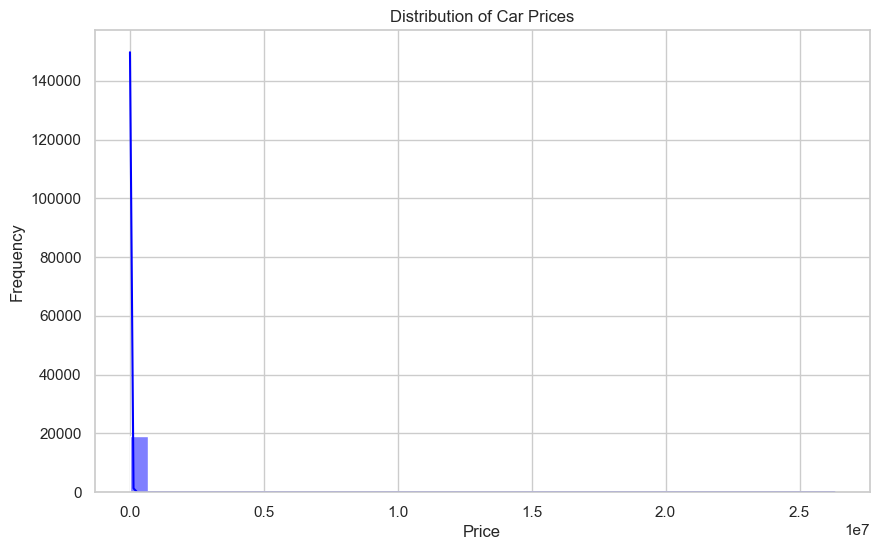

In [13]:
plt.figure(figsize=(10, 6))

# Plot the distribution of the target variable
sns.histplot(df['Price'], bins=40, kde=True, color='blue')

plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 6. Categorical Features vs. Price
We investigate how categorical variables (e.g., fuel type, transmission) affect the car price. A boxplot is excellent for visualizing the median, quartiles, and potential outliers across different categories.

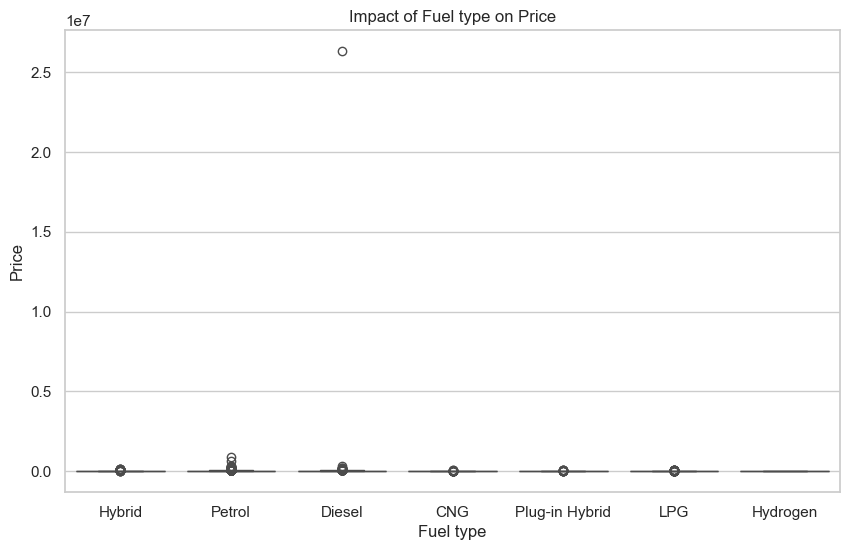

In [19]:
plt.figure(figsize=(10, 6))

# Boxplot for a categorical feature vs price (change 'fuel_type' if needed)
sns.boxplot(x='Fuel type', y='Price', data=df)

plt.title('Impact of Fuel type on Price')
plt.xlabel('Fuel type')
plt.ylabel('Price')
plt.show()

# 7. Correlation Heatmap
The correlation heatmap displays the linear relationship between numerical features. Features with a high positive or negative correlation with the 'price' column are strong predictors for our machine learning model.

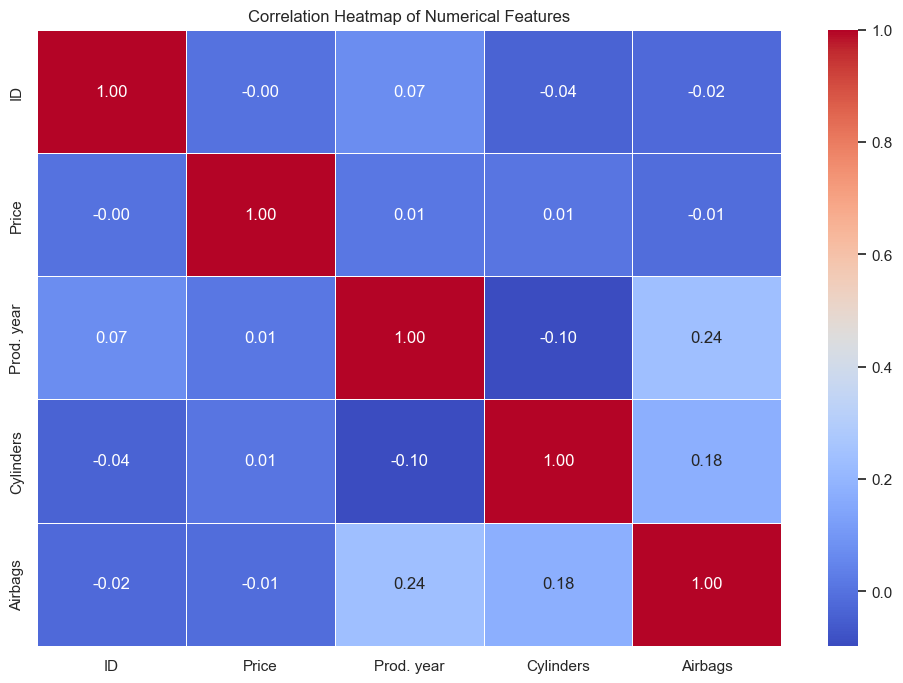

In [8]:
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation calculation
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Plot the correlation heatmap
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 8. Conclusion and Next Steps
Based on the Exploratory Data Analysis (EDA), we observed the following points to be addressed in the Preprocessing stage:
1. **Missing Values:** There are missing values in columns such as `[Column_Name_1]` and `[Column_Name_2]` which need imputation.
2. **Categorical Encoding:** Text-based features like `[Categorical_Column_Name]` need to be converted into numerical formats using encoding techniques.
3. **Key Features:** According to the correlation heatmap, the features most strongly correlated with the price are `[Feature_1]` and `[Feature_2]`.
4. **Outliers:** `[Mention if you noticed any extreme price values that might need handling]`.